# 출력 값 비교
역방향 체인의 성분 추적

## 0. 셋업

In [181]:
import os, sys, time

sys.path.insert(0, os.path.abspath("."))

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import stats

import t_diffusion as td

import matplotlib.font_manager as fm
_have = {f.name for f in fm.fontManager.ttflist}
KFONT = next((f for f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans KR"]
              if f in _have), None)
if KFONT:
    plt.rcParams["font.family"] = KFONT
plt.rcParams["axes.unicode_minus"] = False

from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
_PLAIN = FuncFormatter(lambda v, _: f"{v:g}")

def _minor(v, _):
    if v == 0:
        return ""
    m = abs(v) / 10 ** np.floor(np.log10(abs(v)))
    return f"{v:g}" if round(m) in (2, 3, 5) else ""

_MINOR = FuncFormatter(_minor)

def plain_ticks(ax, axis="y"):
    a = ax.yaxis if axis == "y" else ax.xaxis
    a.set_major_formatter(_PLAIN)
    a.set_minor_formatter(_MINOR)

NU_DATA, LOC, SCALE = 3.0, 0.0, 1.0
NU_MODEL = [3.0, 10.0, 30.0, 500.0]
N_TOTAL, N_TRAIN, M_DATA = 50000, 10000, 10000
T = 1000
SEED = 0
CHUNK = 4000

N_CHAIN = 4000                      # 퍼짐 곡선을 그릴 체인 수
T_GRID = list(range(999, 0, -20)) + [0]
T_SNAP = [999, 500, 100, 1]         # 산포를 찍을 시점

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

KEYS = ["mu", "sb2", "x", "D", "s", "eps"]
NAME = ["평균  mu_theta", "sigmabar_t^2  (스케줄 분산)", "x_t  (역방향 상태)",
        "D  (denoiser)", "s_t = (nu+delta')/(nu+d)", "eps_t  (t 난수)"]
SHORT = ["평균", "sb^2", "x_t", "D", "s_t", "eps"]
COL = ["tab:green", "tab:brown", "tab:blue", "k", "tab:purple", "tab:orange"]
SIGNED = [True, False, True, True, False, True]

print("device =", DEVICE, "| nu =", NU_MODEL)

device = cuda | nu = [3.0, 10.0, 30.0, 500.0]


## 1. 데이터와 denoiser

In [182]:
def make_data():
    rng = np.random.default_rng(SEED)
    pool = stats.t.rvs(df=NU_DATA, loc=LOC, scale=SCALE, size=N_TOTAL, random_state=rng)
    idx = rng.permutation(N_TOTAL)
    return pool[idx[:N_TRAIN]], pool[idx[N_TRAIN:]]

train_np, held = make_data()
X0 = torch.tensor(train_np[:M_DATA], dtype=torch.float32, device=DEVICE)
sch = td.Schedule(T, device=DEVICE)

Q999 = float(stats.t.ppf(0.999, NU_DATA, LOC, SCALE))
print(f"data ~ t(nu={NU_DATA:g}) | train {len(train_np)} | t({NU_DATA:g}) q99.9 = {Q999:.2f}")

@torch.no_grad()
def exact_denoiser(x, i, nu):
    out = torch.empty_like(x)
    for s in range(0, x.shape[0], CHUNK):
        z = (x[s:s + CHUNK] - sch.mu[i] * X0[None, :]) / sch.sigma[i]
        w = torch.softmax(-0.5 * (nu + 1.0) * torch.log1p(z * z / nu), dim=1)
        out[s:s + CHUNK] = (w @ X0)[:, None]                               # E[x_0 | x_t]
    return out

data ~ t(nu=3) | train 10000 | t(3) q99.9 = 10.21


## 2. 역방향 체인의 성분 기록

In [183]:
QS = [0.1, 1, 10, 25, 50, 75, 90, 99, 99.9]

@torch.no_grad()
def run_chain(nu, n=N_CHAIN, seed=SEED):
    torch.manual_seed(seed)
    d = 1
    x = td.sample_mvt_noise(n, d, nu, DEVICE) * sch.sigma[T - 1]
    band = {k: [] for k in ["t"] + KEYS}
    snap = {}

    def rec(i, vals):
        band["t"].append(i)
        for k in KEYS:
            band[k].append(np.percentile(vals[k], QS))
        if i in T_SNAP:
            snap[i] = {k: vals[k].copy() for k in KEYS}

    for i in reversed(range(T)):
        D = exact_denoiser(x, i, nu)
        mu_theta = sch.ct[i] * x + sch.c0[i] * D

        if i == 0:
            if i in T_GRID or i in T_SNAP:
                rec(i, dict(mu=mu_theta.squeeze(-1).cpu().numpy(),
                            x=x.squeeze(-1).cpu().numpy(),
                            D=D.squeeze(-1).cpu().numpy(),
                            sb2=np.full(n, np.nan), s=np.full(n, np.nan),
                            eps=np.zeros(n)))
            x = mu_theta
            break

        delta = ((x - sch.mu[i] * D) / sch.sigma[i]).pow(2).sum(-1, keepdim=True)
        s = (nu + delta) / (nu + d)
        eps = td.sample_mvt_noise(n, d, nu + d, DEVICE)

        if i in T_GRID or i in T_SNAP:
            rec(i, dict(mu=mu_theta.squeeze(-1).cpu().numpy(),
                        x=x.squeeze(-1).cpu().numpy(),
                        D=D.squeeze(-1).cpu().numpy(),
                        sb2=np.full(n, float(sch.sigmabar2[i])),
                        s=s.squeeze(-1).cpu().numpy(),
                        eps=eps.squeeze(-1).cpu().numpy()))

        x = mu_theta + (sch.sigmabar2[i] * s).sqrt() * eps

    for k in KEYS:
        band[k] = np.array(band[k])
    band["t"] = np.array(band["t"])
    return band, snap, x.squeeze(-1).cpu().numpy()

RES = {}
for nu in NU_MODEL:
    RES[nu] = run_chain(nu)
    print(f"  nu={nu:g} 완료", flush=True)

  nu=3 완료
  nu=10 완료
  nu=30 완료
  nu=500 완료


## 3. 개별 표본 100개

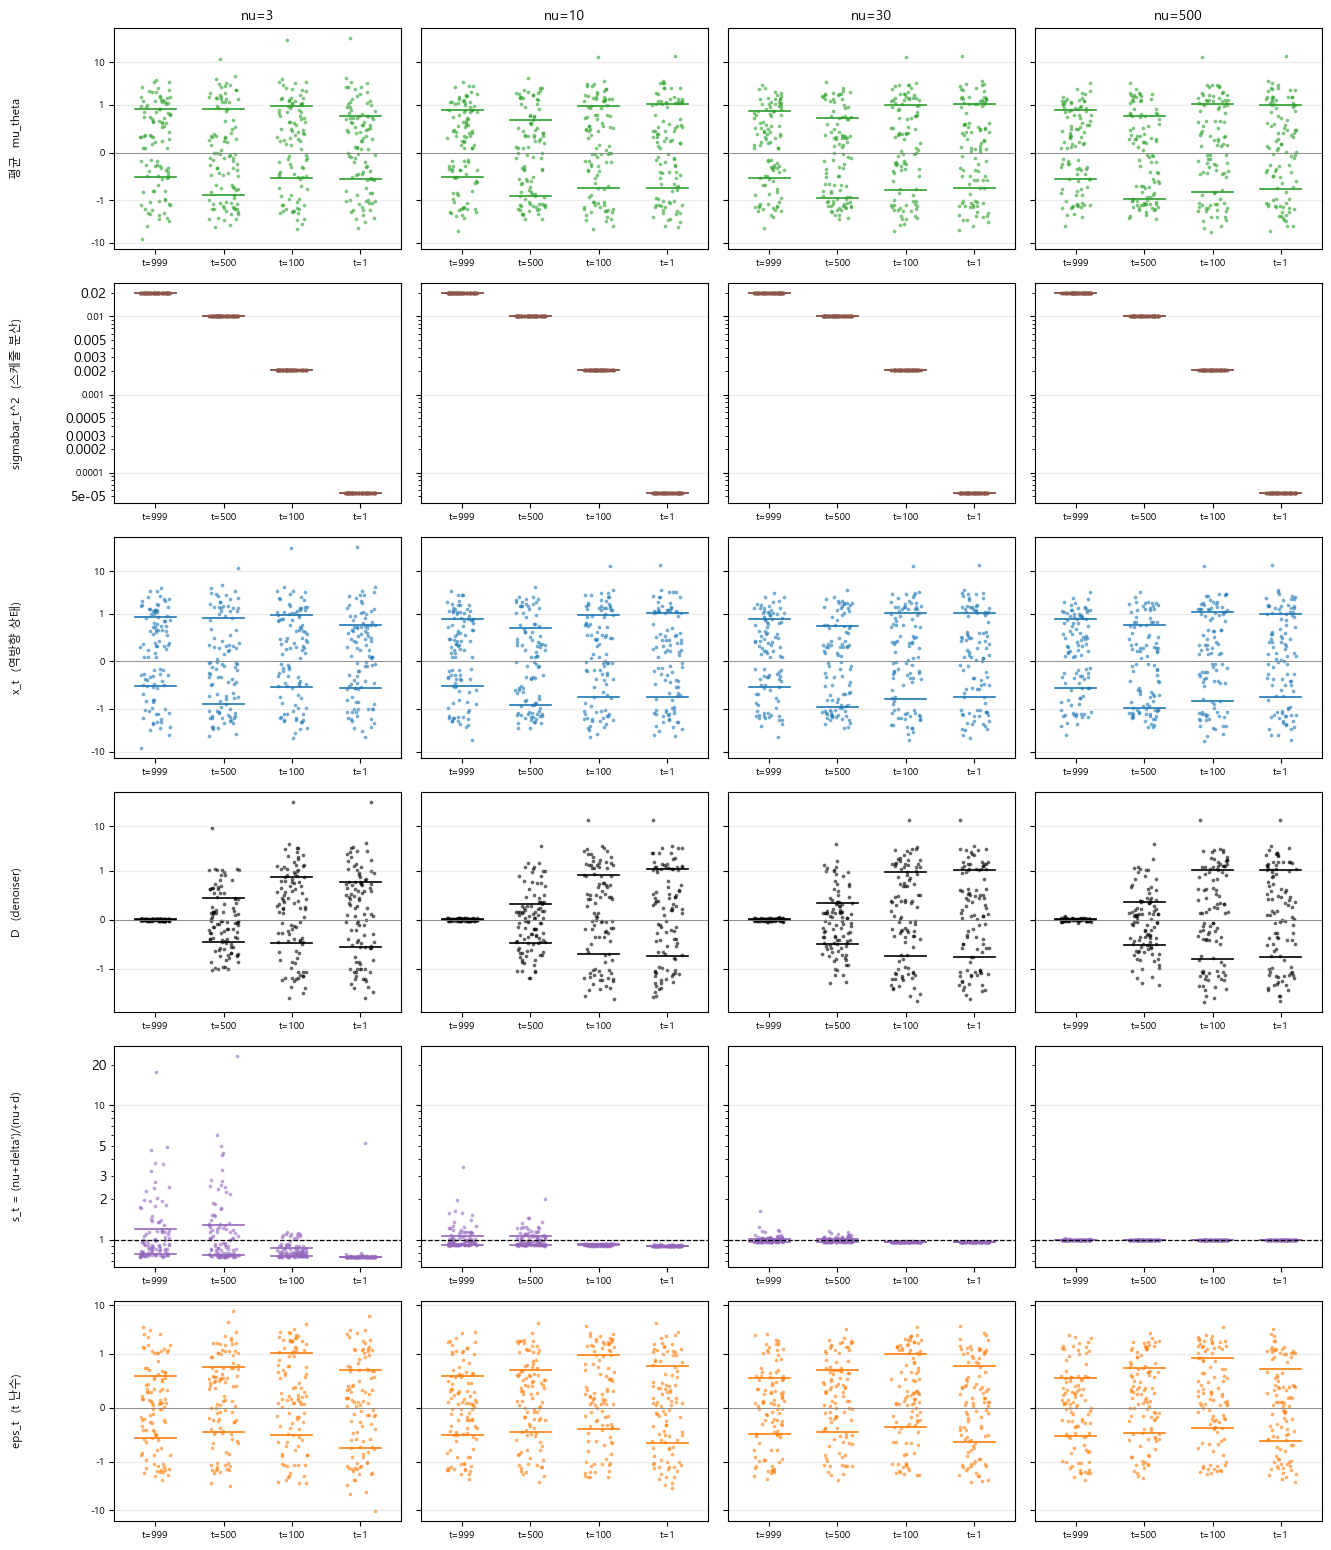

In [184]:
N_SHOW = 100
_j = np.random.default_rng(0)

fig, axes = plt.subplots(len(KEYS), len(NU_MODEL),
                         figsize=(3.3 * len(NU_MODEL), 2.6 * len(KEYS)),
                         squeeze=False, sharey="row")
for r_, (key, lab, col, sg) in enumerate(zip(KEYS, NAME, COL, SIGNED)):
    for c_, nu in enumerate(NU_MODEL):
        ax = axes[r_][c_]
        for k, i in enumerate(T_SNAP):
            v = RES[nu][1][i][key][:N_SHOW]
            v = v[np.isfinite(v)]
            if len(v) == 0:                     # t=0 의 sigmabar^2 / s_t 는 정의 안 됨
                continue
            ax.scatter(k + _j.uniform(-0.22, 0.22, len(v)), v, s=7, alpha=0.6,
                       color=col, linewidths=0)
            q1, q3 = np.percentile(v, [25, 75])
            for q in (q1, q3):
                ax.plot([k - 0.3, k + 0.3], [q, q], color=col, lw=1.2)
        if sg:
            ax.axhline(0, color="gray", lw=0.6)
            ax.set_yscale("symlog", linthresh=1.0)
        else:
            ax.set_yscale("log")
        if key == "s":
            ax.axhline(1.0, color="k", lw=0.9, ls="--")
        plain_ticks(ax)
        ax.set_xticks(range(len(T_SNAP)))
        ax.set_xticklabels([f"t={i}" for i in T_SNAP], fontsize=7)
        ax.set_xlim(-0.6, len(T_SNAP) - 0.4)
        ax.grid(alpha=0.25, axis="y")
        ax.tick_params(labelsize=7)
        if r_ == 0:
            ax.set_title(f"nu={nu:g}", fontsize=10)
        if c_ == 0:
            ax.annotate(lab, xy=(-0.34, 0.5), xycoords="axes fraction",
                        rotation=90, va="center", ha="center", fontsize=8.5)
fig.tight_layout()
plt.show()